In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataframe
df = pd.read_csv('shoreline_validation_results.csv')

# Display the first few rows and columns to understand the structure
print(df.head())
print(df.info())
print(df['experiment'].unique()) # Check for experiment identifiers if any

    experiment    site          direction       N       RMSE        MAE  \
0  exp1_bilstm  agrelo  oblique-rectified  313962  34.181205  20.866006   
1  exp1_bilstm  agrelo  rectified-oblique   50153  93.945139  58.144454   
2  exp1_bilstm  agrelo      oblique-truth  313962  31.937416  21.679001   
3  exp1_bilstm  agrelo      truth-oblique    2635  71.054881  37.422208   
4  exp1_bilstm  agrelo    rectified-truth   50153  38.236749  24.556023   

          Q3         SD  
0  28.750176  27.073362  
1  94.295375  73.790380  
2  32.312181  23.452531  
3  43.562236  60.413241  
4  33.330115  29.309860  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   experiment  324 non-null    object 
 1   site        324 non-null    object 
 2   direction   324 non-null    object 
 3   N           324 non-null    int64  
 4   RMSE        324 non-null    float64
 5

In [2]:
# Display columns to identify correct names
print(df.columns)
print(df.head())

Index(['experiment', 'site', 'direction', 'N', 'RMSE', 'MAE', 'Q3', 'SD'], dtype='object')
    experiment    site          direction       N       RMSE        MAE  \
0  exp1_bilstm  agrelo  oblique-rectified  313962  34.181205  20.866006   
1  exp1_bilstm  agrelo  rectified-oblique   50153  93.945139  58.144454   
2  exp1_bilstm  agrelo      oblique-truth  313962  31.937416  21.679001   
3  exp1_bilstm  agrelo      truth-oblique    2635  71.054881  37.422208   
4  exp1_bilstm  agrelo    rectified-truth   50153  38.236749  24.556023   

          Q3         SD  
0  28.750176  27.073362  
1  94.295375  73.790380  
2  32.312181  23.452531  
3  43.562236  60.413241  
4  33.330115  29.309860  


### Analysis

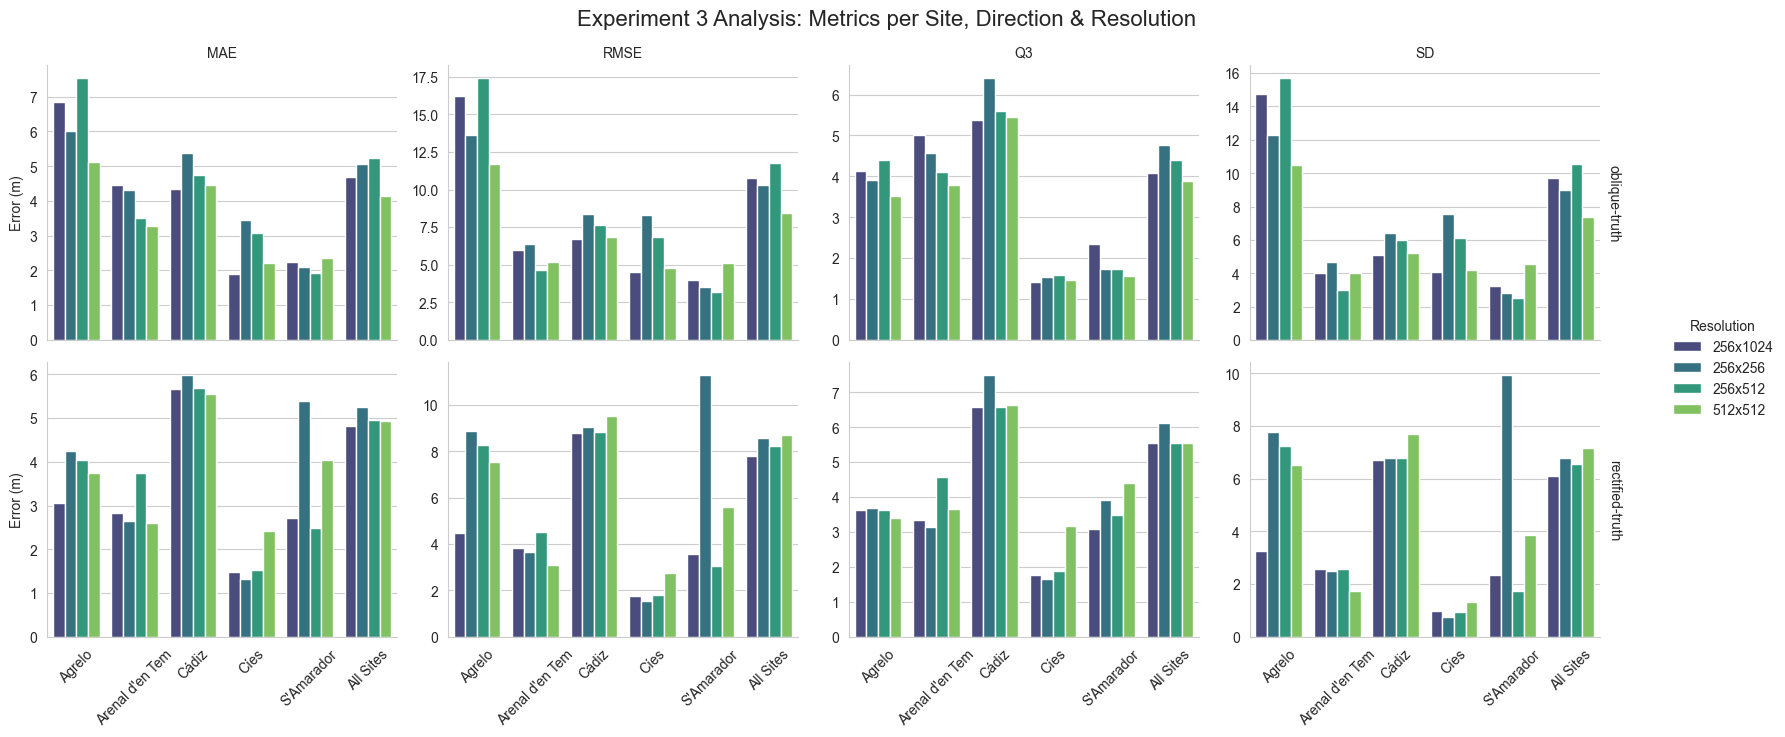

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('shoreline_validation_results.csv')

# Load from experiment 3 only
exp3_filter = df['experiment'].str.contains('exp3', case=False)
dir_filter = df['direction'].isin(['rectified-truth', 'oblique-truth'])
df_exp3 = df[exp3_filter & dir_filter].copy()

# clean direction names
df_exp3['Resolution'] = df_exp3['experiment'].str.replace('exp3_deeplabv3_', '')

site_mapping = {
    'agrelo': 'Agrelo',
    'arenaldentem': "Arenal d'en Tem",
    'cadiz': 'Cádiz',
    'cies': 'Cíes',
    'samarador': "S'Amarador",
    'all': 'All Sites'
}
df_exp3['Site_Label'] = df_exp3['site'].map(site_mapping).fillna(df_exp3['site'].str.title())

metrics = ['MAE', 'RMSE', 'Q3', 'SD']
df_melted = df_exp3.melt(
    id_vars=['Site_Label', 'direction', 'Resolution'], 
    value_vars=metrics, 
    var_name='Metric', 
    value_name='Value (m)'
)

sns.set_style("whitegrid")

g = sns.catplot(
    data=df_melted, 
    kind="bar",
    x="Site_Label", 
    y="Value (m)", 
    hue="Resolution",
    col="Metric", 
    row="direction",
    height=3.5, 
    aspect=1.2,
    palette="viridis", # O 'mako', 'rocket', etc.
    sharey=False,
    margin_titles=True
)

g.set_titles(row_template="{row_name}", col_template="{col_name}")
g.set_axis_labels("", "Error (m)")
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45) 

plt.subplots_adjust(top=0.9)
g.figure.suptitle('Experiment 3 Analysis: Metrics per Site, Direction & Resolution', fontsize=16)

plt.show()

### Rectified = 256x1024; Oblique = 512x512  

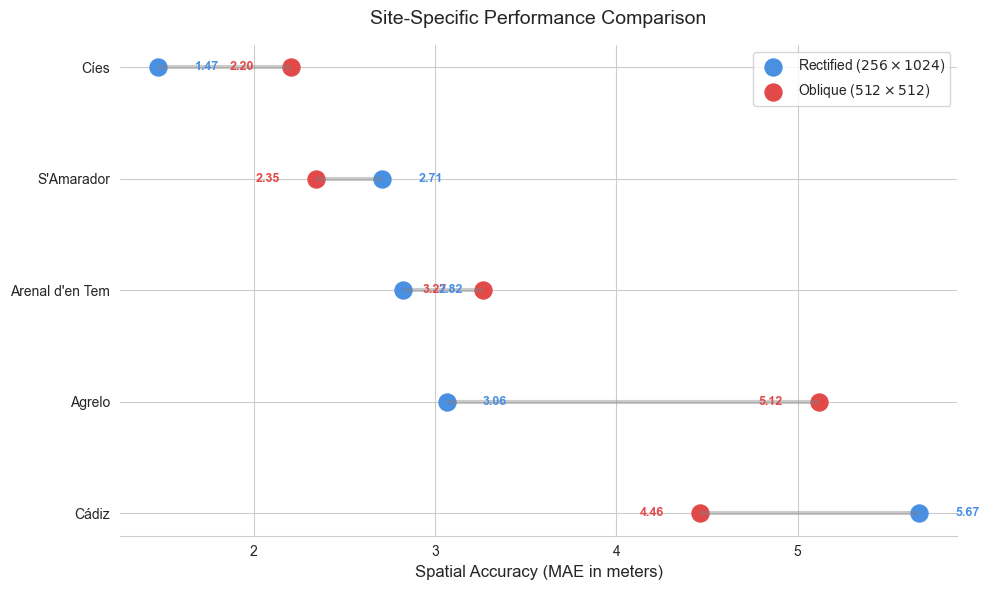

In [4]:
import pandas as pd

# Load data
df = pd.read_csv('shoreline_validation_results.csv')

# Filter data
rect_filter = (df['experiment'] == 'exp3_deeplabv3_256x1024') & (df['direction'] == 'rectified-truth')
oblique_filter = (df['experiment'] == 'exp3_deeplabv3_512x512') & (df['direction'] == 'oblique-truth')

df_rect = df[rect_filter][['site', 'MAE']].rename(columns={'MAE': 'Rectified'})
df_oblique = df[oblique_filter][['site', 'MAE']].rename(columns={'MAE': 'Oblique'})

# Merge
df_plot = pd.merge(df_rect, df_oblique, on='site')

# Capitalize site names for better display
df_plot['Site_Label'] = df_plot['site'].str.replace('_', ' ').str.title()

# Fix site names manually for presentation quality
site_mapping = {
    'agrelo': 'Agrelo',
    'arenaldentem': "Arenal d'en Tem",
    'cadiz': 'Cádiz',
    'cies': 'Cíes',
    'samarador': "S'Amarador",
    'all': 'All Sites'
}
df_plot['Site_Label'] = df_plot['site'].map(site_mapping).fillna(df_plot['site'])

# Sort by Rectified error for visual order
df_plot = df_plot.sort_values('Rectified', ascending=False)

# Remove 'all' if present, based on previous context, though the user code didn't explicitly remove it in the snippet provided.
# However, usually 'all' or 'global' creates a mess in site-specific plots. Let's check if 'all' is in there.
if 'all' in df_plot['site'].values:
    df_plot = df_plot[df_plot['site'] != 'all']

# --- PLOTTING ---
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

# Define y positions
y_range = range(len(df_plot))

# Draw the line
ax.hlines(y=y_range, xmin=df_plot['Oblique'], xmax=df_plot['Rectified'],
          color='grey', alpha=0.4, linewidth=3)

# Draw points
# Rectified
ax.scatter(df_plot['Rectified'], y_range, color='#4A90E2', alpha=1, s=150, label='Rectified ($256 \\times 1024$)')
# Oblique
ax.scatter(df_plot['Oblique'], y_range, color='#E24A4A', alpha=1, s=150, label='Oblique ($512 \\times 512$)')

# Labels and Titles
ax.set_yticks(y_range)
ax.set_yticklabels(df_plot['Site_Label'])
ax.set_xlabel('Spatial Accuracy (MAE in meters)', fontsize=12)
ax.set_title('Site-Specific Performance Comparison', fontsize=14, pad=15)
ax.legend(loc='upper right')

# Remove borders
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Add values next to points
for idx, (i, row) in enumerate(df_plot.iterrows()):
    # Oblique Value - Manually offset x by subtracting a small value
    # Adjust offset based on data scale. Max value is around 9, min is 1.5. 0.2 seems reasonable.
    ax.text(row['Oblique'] - 0.2, idx, f"{row['Oblique']:.2f}",
            va='center', ha='right', color='#E24A4A', fontsize=9, fontweight='bold')
    
    # Rectified Value - Manually offset x by adding a small value
    ax.text(row['Rectified'] + 0.2, idx, f"{row['Rectified']:.2f}",
            va='center', ha='left', color='#4A90E2', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('dumbbell_plot_site_specific_corrected.png')
plt.show()

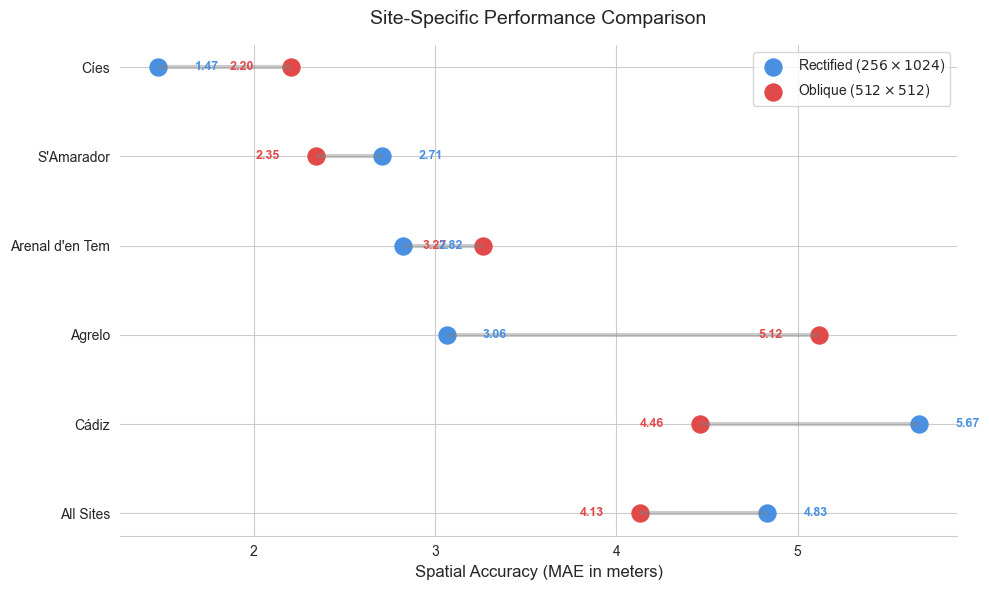

In [5]:
df = pd.read_csv('shoreline_validation_results.csv')

rect_filter = (df['experiment'] == 'exp3_deeplabv3_256x1024') & (df['direction'] == 'rectified-truth')
oblique_filter = (df['experiment'] == 'exp3_deeplabv3_512x512') & (df['direction'] == 'oblique-truth')

df_rect = df[rect_filter][['site', 'MAE']].rename(columns={'MAE': 'Rectified'})
df_oblique = df[oblique_filter][['site', 'MAE']].rename(columns={'MAE': 'Oblique'})

df_plot = pd.merge(df_rect, df_oblique, on='site')

site_mapping = {
    'agrelo': 'Agrelo',
    'arenaldentem': "Arenal d'en Tem",
    'cadiz': 'Cádiz',
    'cies': 'Cíes',
    'samarador': "S'Amarador",
    'all': 'All Sites'
}

df_plot['Site_Label'] = df_plot['site'].map(site_mapping).fillna(df_plot['site'].str.replace('_', ' ').str.title())

mask_all = df_plot['Site_Label'] == 'All Sites'
df_all = df_plot[mask_all]
df_sites = df_plot[~mask_all]

df_sites = df_sites.sort_values('Rectified', ascending=False)

df_final = pd.concat([df_all, df_sites]).reset_index(drop=True)

# --- PLOTTING ---
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

y_range = range(len(df_final))
ax.hlines(y=y_range, xmin=df_final['Oblique'], xmax=df_final['Rectified'],
          color='grey', alpha=0.4, linewidth=3)

ax.scatter(df_final['Rectified'], y_range, color='#4A90E2', alpha=1, s=150, label='Rectified ($256 \\times 1024$)')
ax.scatter(df_final['Oblique'], y_range, color='#E24A4A', alpha=1, s=150, label='Oblique ($512 \\times 512$)')

ax.set_yticks(y_range)
ax.set_yticklabels(df_final['Site_Label'])
ax.set_xlabel('Spatial Accuracy (MAE in meters)', fontsize=12)
ax.set_title('Site-Specific Performance Comparison', fontsize=14, pad=15)
ax.legend(loc='upper right')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

for idx, (i, row) in enumerate(df_final.iterrows()):
    ax.text(row['Oblique'] - 0.2, idx, f"{row['Oblique']:.2f}",
            va='center', ha='right', color='#E24A4A', fontsize=9, fontweight='bold')
    
    ax.text(row['Rectified'] + 0.2, idx, f"{row['Rectified']:.2f}",
            va='center', ha='left', color='#4A90E2', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('dumbbell_plot_site_specific_corrected.png', dpi=300)
plt.show()

### Rectified = 512x512; Oblique = 512x512  

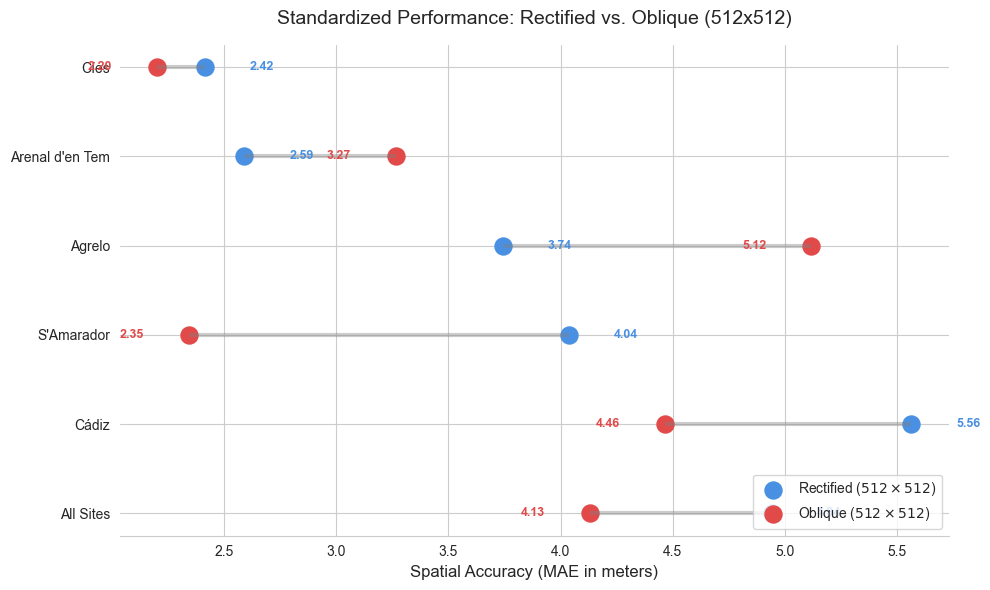

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('shoreline_validation_results.csv')

rect_filter = (df['experiment'] == 'exp3_deeplabv3_512x512') & (df['direction'] == 'rectified-truth')
oblique_filter = (df['experiment'] == 'exp3_deeplabv3_512x512') & (df['direction'] == 'oblique-truth')

df_rect = df[rect_filter][['site', 'MAE']].rename(columns={'MAE': 'Rectified'})
df_oblique = df[oblique_filter][['site', 'MAE']].rename(columns={'MAE': 'Oblique'})

df_plot = pd.merge(df_rect, df_oblique, on='site')

site_mapping = {
    'agrelo': 'Agrelo',
    'arenaldentem': "Arenal d'en Tem",
    'cadiz': 'Cádiz',
    'cies': 'Cíes',
    'samarador': "S'Amarador",
    'all': 'All Sites'
}
df_plot['Site_Label'] = df_plot['site'].map(site_mapping).fillna(df_plot['site'].str.replace('_', ' ').str.title())

mask_all = df_plot['Site_Label'] == 'All Sites'
df_all = df_plot[mask_all]
df_sites = df_plot[~mask_all]

df_sites = df_sites.sort_values('Rectified', ascending=False)

df_final = pd.concat([df_all, df_sites]).reset_index(drop=True)

# --- PLOTTING ---
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

y_range = range(len(df_final))

ax.hlines(y=y_range, xmin=df_final['Oblique'], xmax=df_final['Rectified'],
          color='grey', alpha=0.4, linewidth=3)

ax.scatter(df_final['Rectified'], y_range, color='#4A90E2', alpha=1, s=150, label='Rectified ($512 \\times 512$)')
ax.scatter(df_final['Oblique'], y_range, color='#E24A4A', alpha=1, s=150, label='Oblique ($512 \\times 512$)')

ax.set_yticks(y_range)
ax.set_yticklabels(df_final['Site_Label'])
ax.set_xlabel('Spatial Accuracy (MAE in meters)', fontsize=12)
ax.set_title('Standardized Performance: Rectified vs. Oblique (512x512)', fontsize=14, pad=15)
ax.legend(loc='lower right')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

for idx, (i, row) in enumerate(df_final.iterrows()):
    ax.text(row['Oblique'] - 0.2, idx, f"{row['Oblique']:.2f}",
            va='center', ha='right', color='#E24A4A', fontsize=9, fontweight='bold')
    
    ax.text(row['Rectified'] + 0.2, idx, f"{row['Rectified']:.2f}",
            va='center', ha='left', color='#4A90E2', fontsize=9, fontweight='bold')

plt.tight_layout()
# plt.savefig('dumbbell_plot_512_comparison.png', dpi=300)
plt.show()

#### MAE and RMSD  

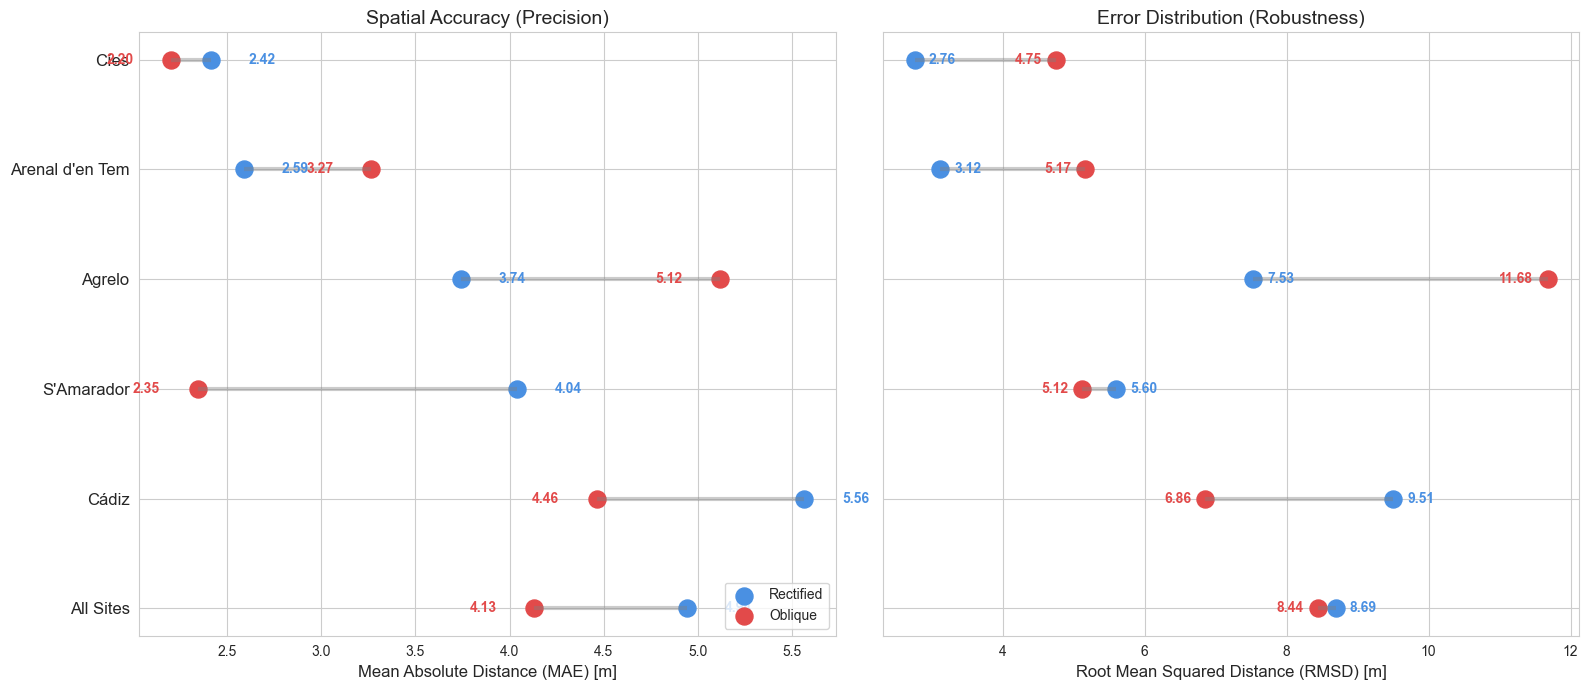

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('shoreline_validation_results.csv')
rect_filter = (df['experiment'] == 'exp3_deeplabv3_512x512') & (df['direction'] == 'rectified-truth')
oblique_filter = (df['experiment'] == 'exp3_deeplabv3_512x512') & (df['direction'] == 'oblique-truth')

# Load MAE and RMSE for both directions
df_rect = df[rect_filter][['site', 'MAE', 'RMSE']].rename(columns={'MAE': 'Rect_MAE', 'RMSE': 'Rect_RMSD'})
df_oblique = df[oblique_filter][['site', 'MAE', 'RMSE']].rename(columns={'MAE': 'Obl_MAE', 'RMSE': 'Obl_RMSD'})
df_plot = pd.merge(df_rect, df_oblique, on='site')

site_mapping = {'agrelo': 'Agrelo', 'arenaldentem': "Arenal d'en Tem", 'cadiz': 'Cádiz', 'cies': 'Cíes', 'samarador': "S'Amarador", 'all': 'All Sites'}
df_plot['Site_Label'] = df_plot['site'].map(site_mapping).fillna(df_plot['site'].str.title())

df_sites = df_plot[df_plot['Site_Label'] != 'All Sites'].sort_values('Rect_MAE', ascending=False)
df_final = pd.concat([df_plot[df_plot['Site_Label'] == 'All Sites'], df_sites]).reset_index(drop=True)

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Subplot 1: MAE ---
y_range = range(len(df_final))
axes[0].hlines(y=y_range, xmin=df_final['Obl_MAE'], xmax=df_final['Rect_MAE'], color='grey', alpha=0.4, linewidth=3)
axes[0].scatter(df_final['Rect_MAE'], y_range, color='#4A90E2', s=150, label='Rectified')
axes[0].scatter(df_final['Obl_MAE'], y_range, color='#E24A4A', s=150, label='Oblique')
axes[0].set_yticks(y_range)
axes[0].set_yticklabels(df_final['Site_Label'], fontsize=12)
axes[0].set_xlabel('Mean Absolute Distance (MAE) [m]', fontsize=12)
axes[0].set_title('Spatial Accuracy (Precision)', fontsize=14)
axes[0].legend(loc='lower right')

# --- Subplot 2: RMSD ---
axes[1].hlines(y=y_range, xmin=df_final['Obl_RMSD'], xmax=df_final['Rect_RMSD'], color='grey', alpha=0.4, linewidth=3)
axes[1].scatter(df_final['Rect_RMSD'], y_range, color='#4A90E2', s=150)
axes[1].scatter(df_final['Obl_RMSD'], y_range, color='#E24A4A', s=150)
axes[1].set_yticks(y_range)
axes[1].set_yticklabels([])
axes[1].set_xlabel('Root Mean Squared Distance (RMSD) [m]', fontsize=12)
axes[1].set_title('Error Distribution (Robustness)', fontsize=14)

for idx, row in df_final.iterrows():
    # Subplot 1
    axes[0].text(row['Obl_MAE']-0.2, idx, f"{row['Obl_MAE']:.2f}", ha='right', va='center', color='#E24A4A', fontweight='bold')
    axes[0].text(row['Rect_MAE']+0.2, idx, f"{row['Rect_MAE']:.2f}", ha='left', va='center', color='#4A90E2', fontweight='bold')
    # Subplot 2
    axes[1].text(row['Obl_RMSD']-0.2, idx, f"{row['Obl_RMSD']:.2f}", ha='right', va='center', color='#E24A4A', fontweight='bold')
    axes[1].text(row['Rect_RMSD']+0.2, idx, f"{row['Rect_RMSD']:.2f}", ha='left', va='center', color='#4A90E2', fontweight='bold')

plt.tight_layout()
plt.show()

### Calculate Improvements 

In [9]:
import pandas as pd

# script to calculate and display improvements between experiments
def calculate_improvements(csv_path):
    df = pd.read_csv(csv_path)
    
    df_global = df[df['site'] == 'all'].copy()
    
    target_directions = ['rectified-truth', 'oblique-truth']
    df_global = df_global[df_global['direction'].isin(target_directions)]

    print("-" * 60)
    print("IMPROVEMENT: EXP 2 (CNNs) vs EXP 1 (BiLSTM)")
    print("-" * 60)
    
    # Define Baseline (BiLSTM)
    baseline_exp1 = df_global[df_global['experiment'] == 'exp1_bilstm']
    
    # Define Experiment 2 models
    exp2_models = df_global[df_global['experiment'].str.contains('exp2', na=False)]
    
    merged_exp2 = pd.merge(
        exp2_models, 
        baseline_exp1[['direction', 'MAE']],
        on='direction', 
        suffixes=('_model', '_baseline')
    )
    
    # Compute % Improvement
    merged_exp2['Imp (%)'] = (
        (merged_exp2['MAE_baseline'] - merged_exp2['MAE_model']) / merged_exp2['MAE_baseline']
    ) * 100
    
    # Print results
    cols = ['experiment', 'direction', 'MAE_baseline', 'MAE_model', 'Imp (%)']
    print(merged_exp2[cols].sort_values(['experiment', 'direction']).round(1).to_string(index=False))
    print("\n")

    print("-" * 60)
    print("IMPROVEMENT: EXP 3 (Resolutions) vs 256x256")
    print("-" * 60)
    
    # Baseline for Experiment 3
    baseline_name_exp3 = 'exp3_deeplabv3_256x256' 
    baseline_exp3 = df_global[df_global['experiment'] == baseline_name_exp3]
    
    if baseline_exp3.empty:
        print(f"Baseline experiment '{baseline_name_exp3}' not found in the data.")
    else:
        # Define other models for Experiment 3
        exp3_models = df_global[
            (df_global['experiment'].str.contains('exp3', na=False)) & 
            (df_global['experiment'] != baseline_name_exp3)
        ]
        
        merged_exp3 = pd.merge(
            exp3_models, 
            baseline_exp3[['direction', 'MAE']], 
            on='direction', 
            suffixes=('_model', '_baseline')
        )
        
        # Compute % Improvement
        merged_exp3['Imp (%)'] = (
            (merged_exp3['MAE_baseline'] - merged_exp3['MAE_model']) / merged_exp3['MAE_baseline']
        ) * 100
        
        print(merged_exp3[cols].sort_values(['experiment', 'direction']).round(1).to_string(index=False))

calculate_improvements('shoreline_validation_results.csv')

------------------------------------------------------------
IMPROVEMENT: EXP 2 (CNNs) vs EXP 1 (BiLSTM)
------------------------------------------------------------
    experiment       direction  MAE_baseline  MAE_model  Imp (%)
  exp2_attunet   oblique-truth          18.7        8.4     55.0
  exp2_attunet rectified-truth          26.5        6.6     75.2
exp2_deeplabv3   oblique-truth          18.7        5.0     72.9
exp2_deeplabv3 rectified-truth          26.5        5.2     80.2
  exp2_ducknet   oblique-truth          18.7        5.3     71.6
  exp2_ducknet rectified-truth          26.5        6.1     76.9
     exp2_unet   oblique-truth          18.7        6.0     67.8
     exp2_unet rectified-truth          26.5        5.9     77.8


------------------------------------------------------------
IMPROVEMENT: EXP 3 (Resolutions) vs 256x256
------------------------------------------------------------
             experiment       direction  MAE_baseline  MAE_model  Imp (%)
exp3_de